# Data Source: Montreal Popular Destinations and Events

In [1]:
import pandas as pd
import time
from geopy.geocoders import Nominatim

from stayrank.config import PROCESSED_DIR, RAW_DESTINATIONS_PATH, RAW_EVENTS_PATH

## Geocoding helper

In [2]:
geocoder = Nominatim(user_agent="stayrank", timeout=10)

def geocode(destination: str):
    query = f"{destination}, Montreal, Quebec, Canada"
    
    location = geocoder.geocode(query)

    time.sleep(1)
    
    if location is None:
        return None

    return {
        "name": destination, 
        "latitude": location.latitude, 
        "longitude": location.longitude
    }

In [3]:
geocode(destination="La Ronde")

{'name': 'La Ronde', 'latitude': 45.523895, 'longitude': -73.5352255}

## Load and geocode popular places

In [4]:
with open(RAW_DESTINATIONS_PATH, "r", encoding="utf-8") as f:
    destinations_list = f.read().splitlines()

places_df = []

for destination in destinations_list:
    coordinates = geocode(destination)
    if coordinates is not None:
        places_df.append(coordinates)
    else:
        print(f"Could not find '{destination}'")

places_df = pd.DataFrame(places_df)

places_df["city"] = "Montreal"
places_df["province"] = "Quebec"
places_df["type"] = "place"

places_df.head()

Could not find 'Little Italy'


,name,latitude,longitude,city,province,type
0,Old Montreal,45.502212,-73.555413,Montreal,Quebec,place
1,Old Port of Montreal,45.504234,-73.552987,Montreal,Quebec,place
2,Mount Royal Park,45.505397,-73.588640,Montreal,Quebec,place
3,Kondiaronk Belvedere,45.503533,-73.587050,Montreal,Quebec,place
4,Parc Jean-Drapeau,45.513864,-73.534333,Montreal,Quebec,place


## Load and geocode Montreal events

In [5]:
events_df = pd.read_csv(RAW_EVENTS_PATH)

mapped_destinations = places_df["name"].unique()

def map_location(location):
    if location in mapped_destinations:
        row = places_df.query(f"name == '{location}'").iloc[0]
        coordinates = {
            "latitude": row["latitude"],
            "longitude": row["longitude"]
        }
    else:
        coordinates = geocode(location)
    
    if coordinates is None:
        return pd.Series({"latitude": None, "longitude": None})
    
    return pd.Series({
        "latitude": coordinates["latitude"],
        "longitude": coordinates["longitude"]
    })

events_df[["latitude", "longitude"]] = events_df["location"].apply(map_location)

# Clean event dataframe
events_df = (
    events_df
    .rename(columns={"event": "name"})
    .assign(
        city="Montreal",
        province="Quebec",
        type="event"
    )
    .drop(columns=["location"])
)

events_df.head()

,name,latitude,longitude,city,province,type
0,Montréal International Jazz Festival,45.508005,-73.565312,Montreal,Quebec,event
1,Les Francos de Montréal,45.508005,-73.565312,Montreal,Quebec,event
2,Osheaga,45.513864,-73.534333,Montreal,Quebec,event
3,ÎleSoniq,45.513864,-73.534333,Montreal,Quebec,event
4,Piknic Électronik,45.513864,-73.534333,Montreal,Quebec,event


## Combine places and events

In [6]:
destinations = (
    pd.concat([places_df, events_df], ignore_index=True)
    .sort_values(by=["type", "name"])
    .reset_index(drop=True)
    .dropna(subset=["latitude", "longitude"])
)

destinations.head(20)

,name,latitude,longitude,city,province,type
0,Fantasia International Film Festival,45.495244,-73.578581,Montreal,Quebec,event
1,Festival International Nuits d'Afrique,45.508005,-73.565312,Montreal,Quebec,event
2,Festival TransAmériques,45.508005,-73.565312,Montreal,Quebec,event
3,Formula 1 Canadian Grand Prix,45.502784,-73.528748,Montreal,Quebec,event
4,Igloofest,45.504234,-73.552987,Montreal,Quebec,event
5,Just For Laughs,45.508005,-73.565312,Montreal,Quebec,event
6,L'International des Feux Loto-Québec,45.513864,-73.534333,Montreal,Quebec,event
7,Lasso Montréal,45.513864,-73.534333,Montreal,Quebec,event
8,Les Francos de Montréal,45.508005,-73.565312,Montreal,Quebec,event
9,MONTRÉAL COMPLÈTEMENT CiRQUE,45.508005,-73.565312,Montreal,Quebec,event


## Visualize outliers

In [7]:
import matplotlib.pyplot as plt

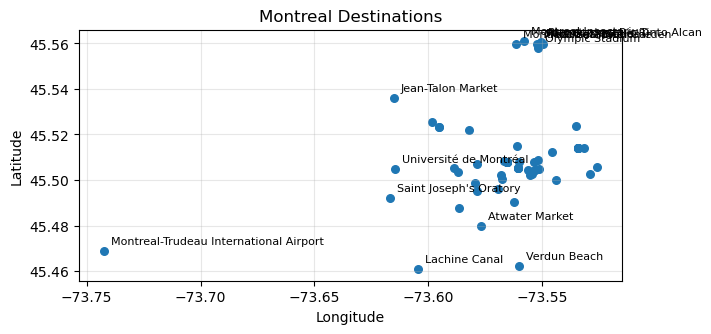

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter plot
ax.scatter(
    destinations["longitude"],
    destinations["latitude"],
    s=30
)

# Identify outliers using the IQR rule
def is_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

outliers = (
    is_outlier(destinations["latitude"]) |
    is_outlier(destinations["longitude"])
)

# Label only outliers
for _, row in destinations[outliers].iterrows():
    ax.annotate(
        row["name"],
        (row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Montreal Destinations")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

plt.show()

All of the destinations and events appear in Montreal. We do not observe any outlier, hence the geocoding was successful.

## Save processed destinations

In [14]:
destinations.isna().sum()

name         0
latitude     0
longitude    0
city         0
province     0
type         0
dtype: int64

In [15]:
CLEAN_DESTINATIONS_PATH = PROCESSED_DIR / "montreal_destinations.parquet"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

destinations.to_parquet(CLEAN_DESTINATIONS_PATH, index=False)

CLEAN_DESTINATIONS_PATH

WindowsPath('C:/Users/ngoum/Documents/coding/data/agentic-pyrank/data/processed/destinations.parquet')